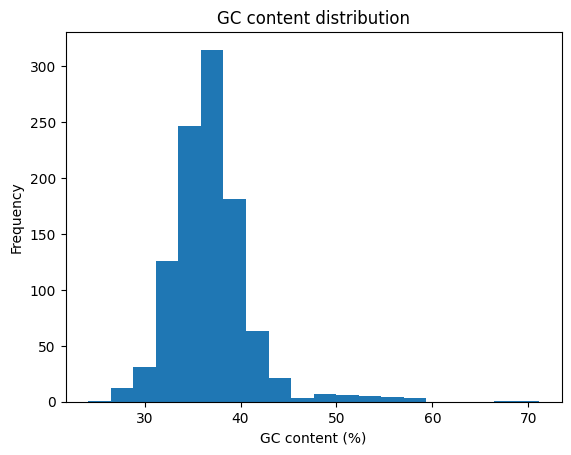

In [2]:
from Bio.SeqUtils import gc_fraction
from Bio import SeqIO
import matplotlib.pyplot as plt

gc_values = [
    gc_fraction(rec.seq) * 100
    for rec in SeqIO.parse("../raw/Gossypium_hirsutum_v2.1_genomic.fna", "fasta")
]

plt.figure()
plt.hist(gc_values, bins=20)
plt.xlabel("GC content (%)")
plt.ylabel("Frequency")
plt.title("GC content distribution")
plt.show()


# Visualisation des séquences en composition de k-mers

In [ ]:
from collections import Counter

def kmer_counts(seq, k=6):
    return Counter(seq[i:i+k] for i in range(len(seq) - k + 1))

record = next(SeqIO.parse("../raw/Gossypium_hirsutum_v2.1_genomic.fna", "fasta"))
counts = kmer_counts(str(record.seq.upper()))

print(counts.most_common(10))


[('AAATTT', 250152), ('AAAATT', 244404), ('AATTTT', 243880), ('ATTTTT', 240973), ('AAAAAT', 240297), ('TTTTTT', 238902), ('AAAAAA', 237033), ('TATTTT', 222733), ('AAAATA', 220438), ('TTATTT', 198615), ('AAATAA', 198017), ('TAAAAT', 190804), ('ATTTTA', 190790), ('TTTTTA', 184429), ('TAAAAA', 183833), ('TTTTAT', 183087), ('ATAAAA', 182931), ('TTTATT', 182774), ('AATAAA', 182462), ('TTAAAA', 180534)]


### Représentations visuelles des séquences pour l'apprentissage automatique

##### Représentation par jeu du chaos (Chaos Game Representation, CGR)

In [1]:
import pandas as pd
sd = pd.read_csv("../processed/splits/sample_test.csv")

In [4]:
seq_nogmo = sd[sd["label"] == 0]["sequence"].tolist()
seq_gmo = sd[sd["label"] == 1]["sequence"].tolist()

In [6]:
seq_nogmo[0]

'...'

In [1]:
res = {'label': 'GMO', 'confidence': 0.9997290968894958, 'probs': {'Non-GMO': 0.000270914810243994, 'GMO': 0.9997290968894958}}

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
def visualize_prediction(result, sequence_preview=50):
    """Create a user-friendly visualization of the prediction."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # --- Left: Probability Bar Chart ---
    ax1 = axes[0]
    labels = ['Non-GMO', 'GMO']
    probs = [result['probs']['Non-GMO'], result['probs']['GMO']]
    colors = ['#2ecc71', '#e74c3c']  # Green, Red
    
    bars = ax1.barh(labels, probs, color=colors, height=0.5)
    ax1.set_xlim(0, 1)
    ax1.set_xlabel('Probability')
    ax1.set_title('Classification Probabilities')
    
    # Add percentage labels on bars
    for bar, prob in zip(bars, probs):
        ax1.text(prob + 0.02, bar.get_y() + bar.get_height()/2, 
                f'{prob*100:.1f}%', va='center', fontsize=12, fontweight='bold')
    
    # --- Right: Confidence Gauge ---
    ax2 = axes[1]
    ax2.set_aspect('equal')
    ax2.axis('off')
    # Background circle
    theta = np.linspace(0, np.pi, 100)
    ax2.fill_between(np.cos(theta), np.sin(theta), 0, color='#ecf0f1', alpha=0.5)
    
    # Confidence arc
    confidence = result['confidence']
    conf_theta = np.linspace(0, np.pi * confidence, 100)
    color = '#2ecc71' if result['label'] == 'Non-GMO' else '#e74c3c'
    ax2.fill_between(np.cos(conf_theta), np.sin(conf_theta), 0, color=color, alpha=0.7)
    
    # Prediction label
    ax2.text(0, 0.5, result['label'], ha='center', va='center', 
             fontsize=24, fontweight='bold', color=color)
    ax2.text(0, 0.15, f"Confidence: {confidence*100:.1f}%", 
             ha='center', va='center', fontsize=14)
    ax2.set_title('Prediction Result')
    
    plt.tight_layout()
    plt.savefig('prediction_result.png', dpi=150, bbox_inches='tight')
    plt.show()

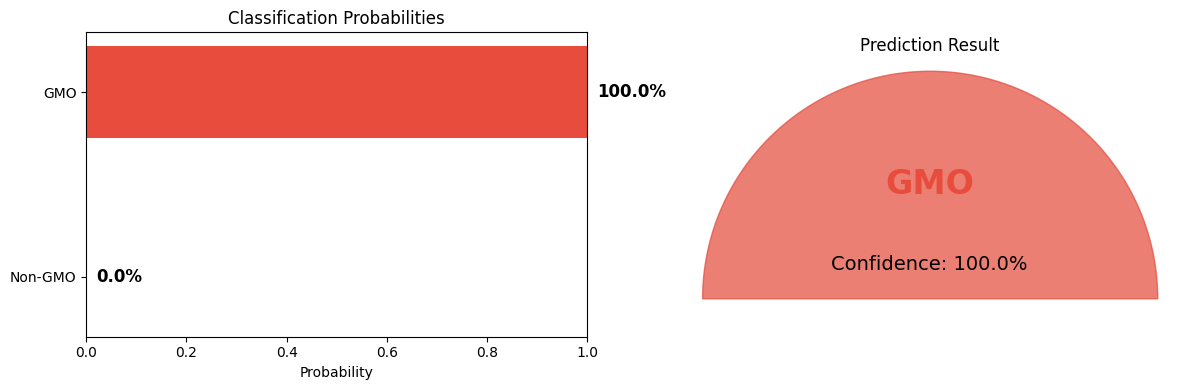

In [6]:
visualize_prediction(res,2048)

In [1]:
import torch
import matplotlib.pyplot as plt

def visualize_with_sequence(result, sequence, model, tokenizer, device, chunk_size=512, top_k_regions=5):
    """Visualize prediction with sequence attention highlights."""
    fig = plt.figure(figsize=(14, 8))
    
    tokens = tokenizer(
        sequence.upper(),
        return_tensors="pt",
        padding="max_length",
        truncation=True,
        max_length=chunk_size
    )
    tokens = {k: v.to(device) for k, v in tokens.items()}
    
    with torch.no_grad():
        # Access base model through PEFT wrapper
        base_encoder = model.encoder.base_model.model if hasattr(model.encoder, 'base_model') else model.encoder
        
        # Enable attention output in config
        base_encoder.config.output_attentions = True
        
        encoder_outputs = base_encoder(
            input_ids=tokens["input_ids"],
            attention_mask=tokens["attention_mask"],
            output_attentions=True
        )
        
        # Check if attentions exist
        if encoder_outputs.attentions is None:
            print("Warning: Model doesn't return attentions. Using gradient-based importance instead.")
            # Fallback: use embedding norms as proxy for importance
            importance = encoder_outputs.last_hidden_state.abs().mean(dim=-1).squeeze().cpu().numpy()
        else:
            attention = encoder_outputs.attentions[-1]
            attention = attention.mean(dim=1).squeeze()
            importance = attention.sum(dim=0).cpu().numpy()
    
    # Rest of the function stays the same...
    # --- Top subplot: Attention heatmap ---
    ax1 = fig.add_subplot(3, 1, 1)
    
    seq_len = min(len(sequence), chunk_size)
    importance = importance[:seq_len]
    importance = (importance - importance.min()) / (importance.max() - importance.min() + 1e-8)
    
    ax1.imshow([importance], aspect='auto', cmap='YlOrRd', interpolation='nearest')
    ax1.set_yticks([])
    ax1.set_xlabel('Position in sequence')
    ax1.set_title('Attention Importance Map (Red = High Attention)')
    cbar = plt.colorbar(ax1.images[0], ax=ax1, orientation='vertical', fraction=0.02)
    cbar.set_label('Importance')
    
    # --- Middle subplot: Top important regions ---
    ax2 = fig.add_subplot(3, 1, 2)
    
    window_size = 50
    region_scores = []
    for i in range(0, len(importance) - window_size, window_size // 2):
        score = importance[i:i+window_size].mean()
        region_scores.append((i, i + window_size, score))
    
    region_scores.sort(key=lambda x: x[2], reverse=True)
    top_regions = region_scores[:top_k_regions]
    
    ax2.axis('off')
    region_text = "Top Important Regions:\n\n"
    for idx, (start, end, score) in enumerate(top_regions, 1):
        region_seq = sequence[start:end].upper()
        region_text += f"{idx}. Position {start}-{end} (score: {score:.3f})\n"
        region_text += f"   {region_seq[:30]}{'...' if len(region_seq) > 30 else ''}\n\n"
    
    ax2.text(0.05, 0.95, region_text, transform=ax2.transAxes, fontsize=10,
             verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax2.set_title('Most Attended Sequence Regions (Potential GMO Markers)')
    
    # --- Bottom subplot: Prediction result ---
    ax3 = fig.add_subplot(3, 1, 3)
    
    labels = ['Non-GMO', 'GMO']
    probs = [result['probs']['Non-GMO'], result['probs']['GMO']]
    colors = ['#27ae60', '#c0392b']
    
    bars = ax3.barh(labels, probs, color=colors, height=0.4)
    ax3.set_xlim(0, 1.1)
    ax3.set_xlabel('Probability')
    
    for bar, prob in zip(bars, probs):
        ax3.text(prob + 0.02, bar.get_y() + bar.get_height()/2,
                f'{prob*100:.1f}%', va='center', fontsize=12, fontweight='bold')
    
    pred_idx = 1 if result['label'] == 'GMO' else 0
    bars[pred_idx].set_edgecolor('gold')
    bars[pred_idx].set_linewidth(3)
    
    ax3.set_title(f"Prediction: {result['label']} (Confidence: {result['confidence']*100:.1f}%)",
                  fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('prediction_with_sequence.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return top_regions

In [3]:
DNA_SEQ = "TATGGCTAGAGCCAGGCAACCGGCTGAGTATAAAAAACAAGCGCCCACAGCTAACGGATTCACTCTGAGCGCCGTCACACTCACAGCTTGTGCGGGATATCATTTGCCTGAAACCGTTTCCCTTAAAGCGAAAAGCCCCCCACCCAAAGGTAAGGAGACGGAGAAATCCTTATTTATAGATTCTTATTTTAGGATGTTTATTAAGTAAACAACGAGCTGATTTGTTTATTTTATGTAAACATGGATGAATTTATTCACTTTAATGCAAACTGTCGTCGGGGACCACGCGGTTCTTTGTCTTCGCAAGAATTGTATTGATTGTTAAACAGCAGTATCTGTATCTTGTGCTTGGCTTTTTTAAAACGAGGAACGGTTATGACTGCAGACAAGTTCATTAGCGCTGCTGCTGCGATTCACAGGTGCTTTTGGATGGAGCCGGCTTCTAGTAAATGGCGTCCTATGAGTTAATGGTTGCGCTAAAACCGGTGTTTGTCACCGTGTAGTCGTGCACGGCTTTTTTTTTTTTTTTTTTTTTTTTGTAGGATTGTGGTGACACTTGGGATTTGATCCCAGGCAGGATACTTTGAAGCGGGTTTCCGAGTTGAGGCTGTCTGGATCCCGGCTGCTCCCTTTGTGCGCCCGATGCGGCGGGGTGTGACCTACTTTAGCATATTAGCCTAGCCACATCATGCTAGCACGCCCTTTAGATTTGCAGCAGTTGCAGTTTTAAGTCTCTCTCGTTTATCCTGGATACTCCCACACACGCTTTTAAAAGATGAATTACTTTCTTTTATTTAACCTAATCTGGTGTCAGTTTATAAGGCTTGCAGTAAAAAGATAGAAGGACTAGCTTTTCTTTTCTTAAAGGTGATAAACTGATTAATAGCTCAAGTGAATGAATGTCCTGATCTGTTTAGTCTTTTCTTATATGTGACAAAGAAATGAGGAAATTGCAAATCAATCGCCTGATCGTCCACTCCGAGAAAAGGCGTGGCTTTCAGGAAATGGATCACCAGTCAAGCGCTTGTGACCGTTCATGAGTCGGCATAAGTTCATTATGCAACTTCCCTTCTCATAAACTAGCTTCAATATTAAGTAATCGCAGACTTCATCTTTTTTAAACGTCTCGTGGTGTGCAATGAATGAGTGTGCTGCTGCATGACGCAGTGATATTCGCTCAAAGGACTTGGAAGGTTCATAAAAGCGAGCGTGATTAAGCAACAGTGGGAGGGCGCTGGTTGTAACGATAGTAAAACGAAGGGAGTGGTCTGTCGGCTAGTCTGTAATGTGGACTGTTCCTTTTTTTTCTCGCCGTGCGTTGCCGCTCTGGCGTCGCGCCACGCGCCGGTAGCCGCAAAGCTGCTCAAAACCGAACCATGTCCTTATATGGTAATAACAGAACGCAGCGCCACTTCCTTTTGTCTGGCTTACTCGGAATGTGCGGCACGAGCTCCTCCTAGCGGCCGAGCTCGTGAACTTCCGCTAGTTAACAGGAAGTAGAAGCGGAATGGCCGCAGGCTTGAGTGCTAATCTTTTTTTTCTTTATCTTTAACAGTTCAGCCATGGAAGATGAAATCGCCGCACTGGTTGTTGACAACGGATCCGGTATGTGCAAGGCCGGATTCGCCGGAGACGACGCCCCTCGTGCTGTCTTCCCCTCCATCGTCGGTCGCCCCAGGCATCAGGTTAGCGACTGCGCATGTCTACTTTTAATGTTACCTTAAATTGTGACTTATGTCATAAATCAGGCCCTAAATCAAGAAAATTGTTCAACTTAATGATATTAACATTAAGATTTTAGTTCAGCTATCACTTGGCAAACACTTAATGATTTCTTTAAATTTTGTTATTTTTGACTTTTTAACTAAAACTGATCTCCTTGTTCAGGGTGTGATGGTGGGTATGGGTCAGAAAGACAGCTACGTTGGTGATGAGGCCCAGAGCAAGAGAGGTATCCTGACCCTGAAGTACCCCATTGAGCACGGTATTGTGACCAACTGGGATGACATGGAGAAGATCTGGCATCACACCTTCTACAACGAGCTGAGAGTTGCCCCTGAGGAGCATCCCGTCCTGCTCACAGAGGCTCCCCTGAACCCCAAAGCCAACAGGGAGAAGATGACCCAGGTACACACCTTTTTTCCACTTGTAATGTTTGGTTAGACCTCAAAGTGTTTATCTCCTCCCCGGTTTCCTTCTGTTCCATTCTCATTTGCTCCTTCCTTCCCCTCCCTCCTCTCCTCCAGGACCTCTCCTCTATAAGATGATCTATCATCAACAGGTCTCTTGACTGTGTGCCTTACCTGCACTTGTGTCTATTTAGGAGAGCAGTAGCTCTGCACTTTATTAGACATTGACTTACTTGCACAAGTGTGAAGGAATGTTTACTTTCTGCACTTTTATTCTACTAACTTCAATCAGCCTCACTCTAATGCATGTAGTGAGTGCAGTGGTCACAAAGGCTAGACTTGTCTTTTTAATTTTGTAAAGCTAAAATGTGTTCTCCCTCTCCTTACAGATCATGTTCGAGACCTTCAACACCCCCGCCATGTACGTTGCCATCCAGGCTGTGCTGTCCCTGTACGCCTCTGGTCGTACCACTGGTATCGTCATGGACTCCGGTGATGGTGTGACCCACACAGTGCCCATCTACGAGGGTTATGCCCTGCCCCACGCCATCCTGCGTCTGGACCTGGCTGGCCGTGACCTCACAGACTACCTCATGAAGATCCTGACAGAGCGTGGCTACTCCTTCACCACCACAGCCGAGAGGGAAATCGTGCGTGACATCAAGGAGAAGCTGTGCTACGTCGCCCTGGACTTCGAGCAGGAGATGGGCACCGCTGCCTCCTCCTCCTCCCTGGAGAAGAGTTACGAGCTGCCTGACGGACAGGTCATCACCATTGGCAATGAGAGGTTCCGTTGCCCTGAGGCCCTCTTCCAGCCTTCCTTCCTTGGTATGTTCCCAACAGAAATCCACCACTTATTAAATCCTCACATGCAAACTGGGCCCTTATGGCATCCTGCAGTTCCACTTGCTAACTGGTGTCTTGTATCTTCTCAGGTATGGAATCCTGCGGAATCCACGAAACCACCTACAACAGCATCATGAAGTGCGACGTCGACATCCGTAAGGACCTGTACGCCAACACCGTGCTGTCTGGAGGTACCACCATGTACCCTGGCATCGCTGACAGGATGCAGAAGGAGATCACAGCCCTGGCCCCATCCACCATGAAGATCAAGGTGAGCTGACTTGCCTTCTAGTGGCATTCATAAGGGTTCAGTTAATGCACTTTTTTTTTAATTTAATTAAGTATCCCAATGACACTCTGCCTCATTGTCCTGCAGATCATCGCCCCACCTGAGCGTAAATACTCCGTCTGGATCGGAGGCTCCATCCTGGCCTCCCTGTCCACCTTCCAGCAGATGTGGATCAGCAAGCAGGAGTACGATGAGTCCGGCCCCTCCATCGTCCACCGCAAATGCTTCTAAACAGACTGTTCCTTCTCCCCTTCCCCAACCAAACGCCCAACAACTTCAGCTCTGTGCAAAACAACCACACACCACACATTTCTCATACACAACTCAGGCGCAGAGAATAGATGACCAACTCATTGGCATGGCTTCAGTTATTTTTGGCGCTTGACTCAGGATTAAAAAAAAAAACTGGAACGATGAAGGAGACAGTAATGTTTTTGGCTAGGTTTTAAAAAAGACACCCCAGGGTTCTGCAGTCTCATCTGGGGCTTAAAAAAAAATGTACATTTTGTTTTTCTTTAAGTCATTCCAAATGTTTGTTAACTGCATTGTTCAGACACATGATTCCAAATGTTAACTTGCATTGTTCAGATACGTATTTGCCTCTGTGAAGGCTGCCCAGTGGTTGGCGCATACTTAACATGGTTGTAGTATCGCTTGTATGTAAGTTATGTCTGGGTTTTTTGTACTTTCAGCCTTAAAAGAATCTTGGTCCTGTTTAATTTTTGTTTTTGTTATGCAAACCCTCATCCTGACCCCACTTCTCCCCCCACGTTGGGAGGCTTCATCCCTGGGGCGGTGGGGCAAGGGGGTGTCTCGGAATGATGGGGTAAACATGGGGTGCCAGACCGGTGGGGCCAACCTGTACACTGACTAAACAATCCCAATAAAGTGCACATGTGTTCCGAA"

In [15]:
from peft import LoraConfig, get_peft_model
import torch
from Tuning import NTForGMO
import torch
from transformers import AutoTokenizer


# DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE = torch.device("cpu")
MAX_LENGTH = 2048
MODEL_NAME = "InstaDeepAI/nucleotide-transformer-V2-250m-multi-species"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)

model = NTForGMO(MODEL_NAME)
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["query", "value"],
    lora_dropout=0.1,
    bias="none",
)
model.encoder = get_peft_model(model.encoder, lora_config)


Some weights of EsmModel were not initialized from the model checkpoint at InstaDeepAI/nucleotide-transformer-V2-250m-multi-species and are newly initialized: ['encoder.layer.0.intermediate.dense.bias', 'encoder.layer.0.output.dense.bias', 'encoder.layer.1.intermediate.dense.bias', 'encoder.layer.1.output.dense.bias', 'encoder.layer.10.intermediate.dense.bias', 'encoder.layer.10.output.dense.bias', 'encoder.layer.11.intermediate.dense.bias', 'encoder.layer.11.output.dense.bias', 'encoder.layer.12.intermediate.dense.bias', 'encoder.layer.12.output.dense.bias', 'encoder.layer.13.intermediate.dense.bias', 'encoder.layer.13.output.dense.bias', 'encoder.layer.14.intermediate.dense.bias', 'encoder.layer.14.output.dense.bias', 'encoder.layer.15.intermediate.dense.bias', 'encoder.layer.15.output.dense.bias', 'encoder.layer.16.intermediate.dense.bias', 'encoder.layer.16.output.dense.bias', 'encoder.layer.17.intermediate.dense.bias', 'encoder.layer.17.output.dense.bias', 'encoder.layer.18.interm

In [16]:
# Put model in eval mode
model.eval()

# Call visualization with proper error handling
# try:
top_regions = visualize_with_sequence(res, DNA_SEQ, model, tokenizer, DEVICE, MAX_LENGTH)
# except Exception as e:
#     print(f"Visualization failed: {e}")
#     top_regions = []
    
# Print the important regions
print("\n=== Potential GMO regions ===")
for start, end, score in top_regions:
    print(f"Position {start}-{end}: {DNA_SEQ[start:end][:50]}...")

ValueError: The `output_attentions` attribute is not supported when using the `attn_implementation` set to sdpa. Please set it to 'eager' instead.

<Figure size 1400x800 with 0 Axes>